# Clustering Semantico e Sentiment Analysis delle domande

In [ ]:
!pip install huggingface_hub
!pip install contractions

In [ ]:
# Librerie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

import nltk
import contractions
from nltk import word_tokenize, pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer
from textblob import TextBlob

from huggingface_hub import notebook_login
from huggingface_hub.hf_api import HfFolder
HfFolder.save_token("TOKEN")

# Scarica risorse necessarie (una sola volta)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

In [3]:
# Preprocessing dataset
df_raw = pd.read_csv('/kaggle/input/nlp-mental-health-conversations/train.csv')

# Filtra le righe in cui 'Response' o 'Context' sono non vuoti
df_clean = df_raw.dropna(subset=['Response', 'Context'], how='any')
df = df_clean.copy()

# Rimuove i caratteri '\n' nelle due colonne
df['Response'] = df['Response'].str.replace('\n', ' ', regex=True)
df['Context'] = df['Context'].str.replace('\n', ' ', regex=True)

domande_counts = df['Context'].value_counts()
unique_domande = domande_counts[domande_counts == 1].index
df_domande = df[df['Context'].isin(unique_domande)][['Context']].reset_index(drop=True)

### Embedding delle risposte con SentenceTransformer: 
Per trasformare le frasi in vettori numerici viene usato il modello preaddestrato 'all-MiniLM-L6-v2'

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df_domande['Context'].tolist())

### Clustering tramite KMeans

In [8]:
# PCA per KMeans
pca = PCA(n_components=5)
reduced_KMeans = pca.fit_transform(embeddings)

# KMeans
n_clusters = 3
kmeans = KMeans(n_init='auto', n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(reduced_KMeans)
df_domande['cluster'] = labels

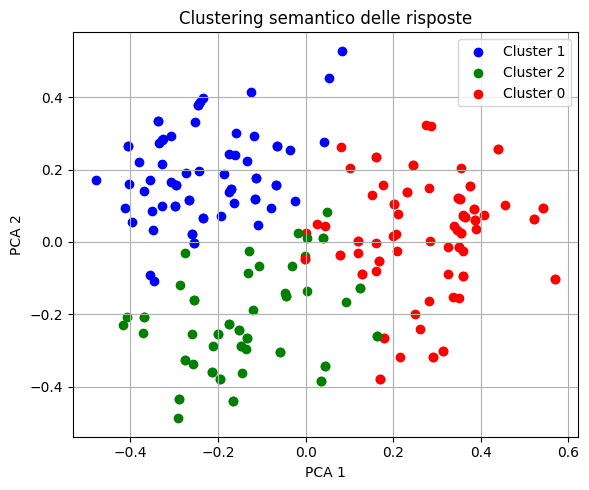

In [17]:
# PCA per visualizzazione
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(6, 5))
colors = ['red', 'blue', 'green']
for i, (x, y) in enumerate(reduced):
    plt.scatter(x, y, color=colors[labels[i]], label=f'Cluster {labels[i]}' if f'Cluster {labels[i]}' not in plt.gca().get_legend_handles_labels()[1] else "")
plt.title("Clustering semantico delle risposte")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('clustering_semantico.png', bbox_inches='tight')
plt.show()

### Parole chiave e sentiment analysis

In [11]:
# Inizializza il lemmatizzatore
lemmatizer = WordNetLemmatizer()

# Lista stopword personalizzata da escludere
custom_stopwords = set([
    "thing", "anything", "lot", "time", 
    "year", "people", "someone", "something", 
    "life", "month", "point", "way", "issue",
    "interest", "nothing", "problem", "everything",
    "day"
])

# Mappa i tag Penn Treebank a WordNet
def penn_to_wordnet(tag):
    if tag.startswith('N'):
        return wordnet.NOUN
    else:
        return None

# Espande contrazioni
def expand_contractions(text):
    return contractions.fix(text)

# Tokenizer con POS tagging, filtro, lemmatizzazione e stopword personalizzate
def custom_tokenizer(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    
    lemmatized = []
    for word, tag in tagged_tokens:
        if len(word) > 2 and word not in custom_stopwords:  # filtro lunghezza + stopword personalizzate
            wn_tag = penn_to_wordnet(tag)
            if wn_tag == wordnet.NOUN:
                lemma = lemmatizer.lemmatize(word, pos=wn_tag)
                if lemma not in custom_stopwords:  # stopword anche dopo lemmatizzazione
                    lemmatized.append(lemma)
    
    return lemmatized

### 🧠 Cluster 1 (87 domande)

📌 Parole chiave: boyfriend, feeling, friend, girl, guy, husband, money, parent, relationship, woman

### 🧠 Cluster 2 (69 domande)

📌 Parole chiave: anxiety, body, boyfriend, depression, feeling, friend, girl, nightmare, relationship, school

### 🧠 Cluster 3 (61 domande)

📌 Parole chiave: adult, child, dad, daughter, family, home, mom, mother, son, wife

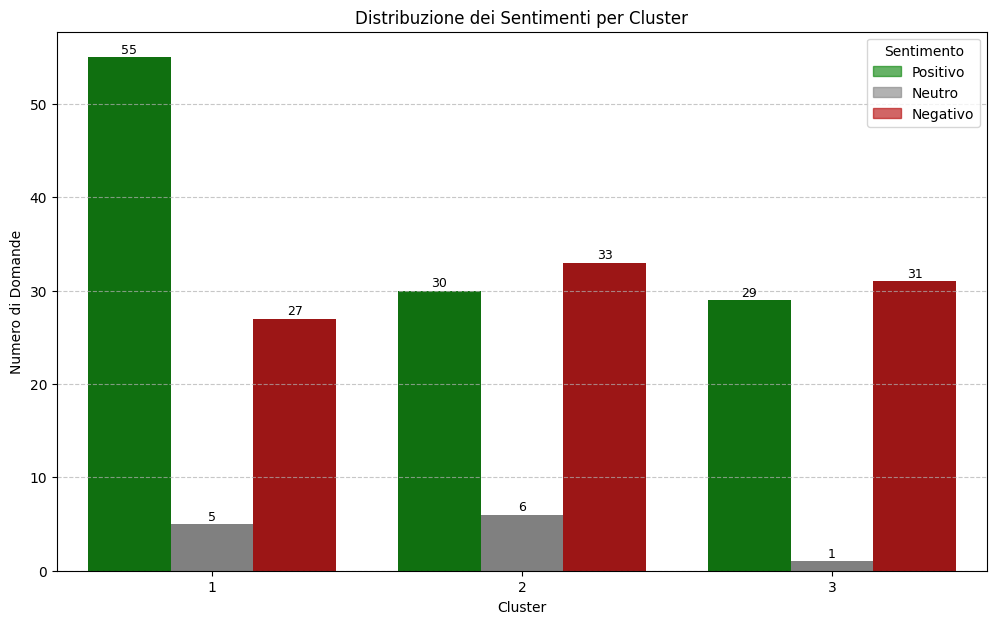

In [14]:
import matplotlib.patches as mpatches

# Analisi qualitativa per ogni cluster
all_data = []

for cluster_id in range(n_clusters):
    cluster_domande = df_domande[df_domande['cluster'] == cluster_id]['Context'].tolist()
    
    # Espandi contrazioni
    cluster_domande = [expand_contractions(t) for t in cluster_domande]
    
    # TF-IDF e parole chiave
    tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, lowercase=True, max_features=10, token_pattern=None)
    tfidf_matrix = tfidf.fit_transform(cluster_domande)
    keywords = tfidf.get_feature_names_out()

    # Mostra info cluster
    cluster_title = f"🧠 Cluster {cluster_id+1} ({len(cluster_domande)} domande)"
    keyword_line  = f"📌 Parole chiave: {', '.join(keywords)}"
    display(Markdown(f"### {cluster_title}"))
    display(Markdown(f"{keyword_line}"))

    # Calcola sentiment per ogni frase nel cluster
    for text in cluster_domande:
        polarity = TextBlob(text).sentiment.polarity
        sentiment = 'positivo' if polarity > 0 else 'negativo' if polarity < 0 else 'neutro'
        all_data.append({'cluster': cluster_id+1, 'sentiment': sentiment})

# Crea un dataframe aggregato
df_all = pd.DataFrame(all_data)

# Palette colori con trasparenza (alpha)
palette = {
    'positivo': (0, 0.5, 0, 0.6),  # verde trasparente
    'neutro': (0.5, 0.5, 0.5, 0.6), # grigio trasparente
    'negativo': (0.7, 0, 0, 0.6)    # rosso trasparente
}

plt.figure(figsize=(12,7))
ax = sns.countplot(
    data=df_all, x='cluster', hue='sentiment', order=range(1,n_clusters+1),
    hue_order=['positivo','neutro','negativo'],
    palette=palette
)

plt.title("Distribuzione dei Sentimenti per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Numero di Domande")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Aggiungi quantità sopra ogni barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.1,
            s=int(height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Crea legenda personalizzata con numero totale parole
handles = [
    mpatches.Patch(color=palette['positivo'], label=f"Positivo"),
    mpatches.Patch(color=palette['neutro'], label=f"Neutro"),
    mpatches.Patch(color=palette['negativo'], label=f"Negativo")
]

plt.legend(title='Sentimento', handles=handles, loc='upper right')
plt.savefig('distribuzione_sentimenti_cluster.png', bbox_inches='tight')
plt.show()


In [18]:
print(df_domande.iloc[0])

Context    I'm not suicidal and wouldn't take my own life...
cluster                                                    1
Name: 0, dtype: object


In [16]:
print(cluster_domande[0])

I am the problem. I make my family argue because of me. My mom has even said it. It is constantly like this. I because problems. I am worthless. I cannot stop crying. Sometimes I have to cry myself to sleep. I cannot even leave my room because my family cannot stand me.
